# Estimated Haplotype Post Analysis

- See if log likelihood converged to the right haplotype frequency
- See if the estimated haplotype frequencies are close to the true haplotype frequencies throughout all samples
- See if the estimated haplotypes exist in the true haplotypes, wrongly estimated haplotypes that are not in the true haplotype set, and haplotypes that weren't estimated but existed in the true haplotypes. Shows the relationship between haplotypes and an MST.

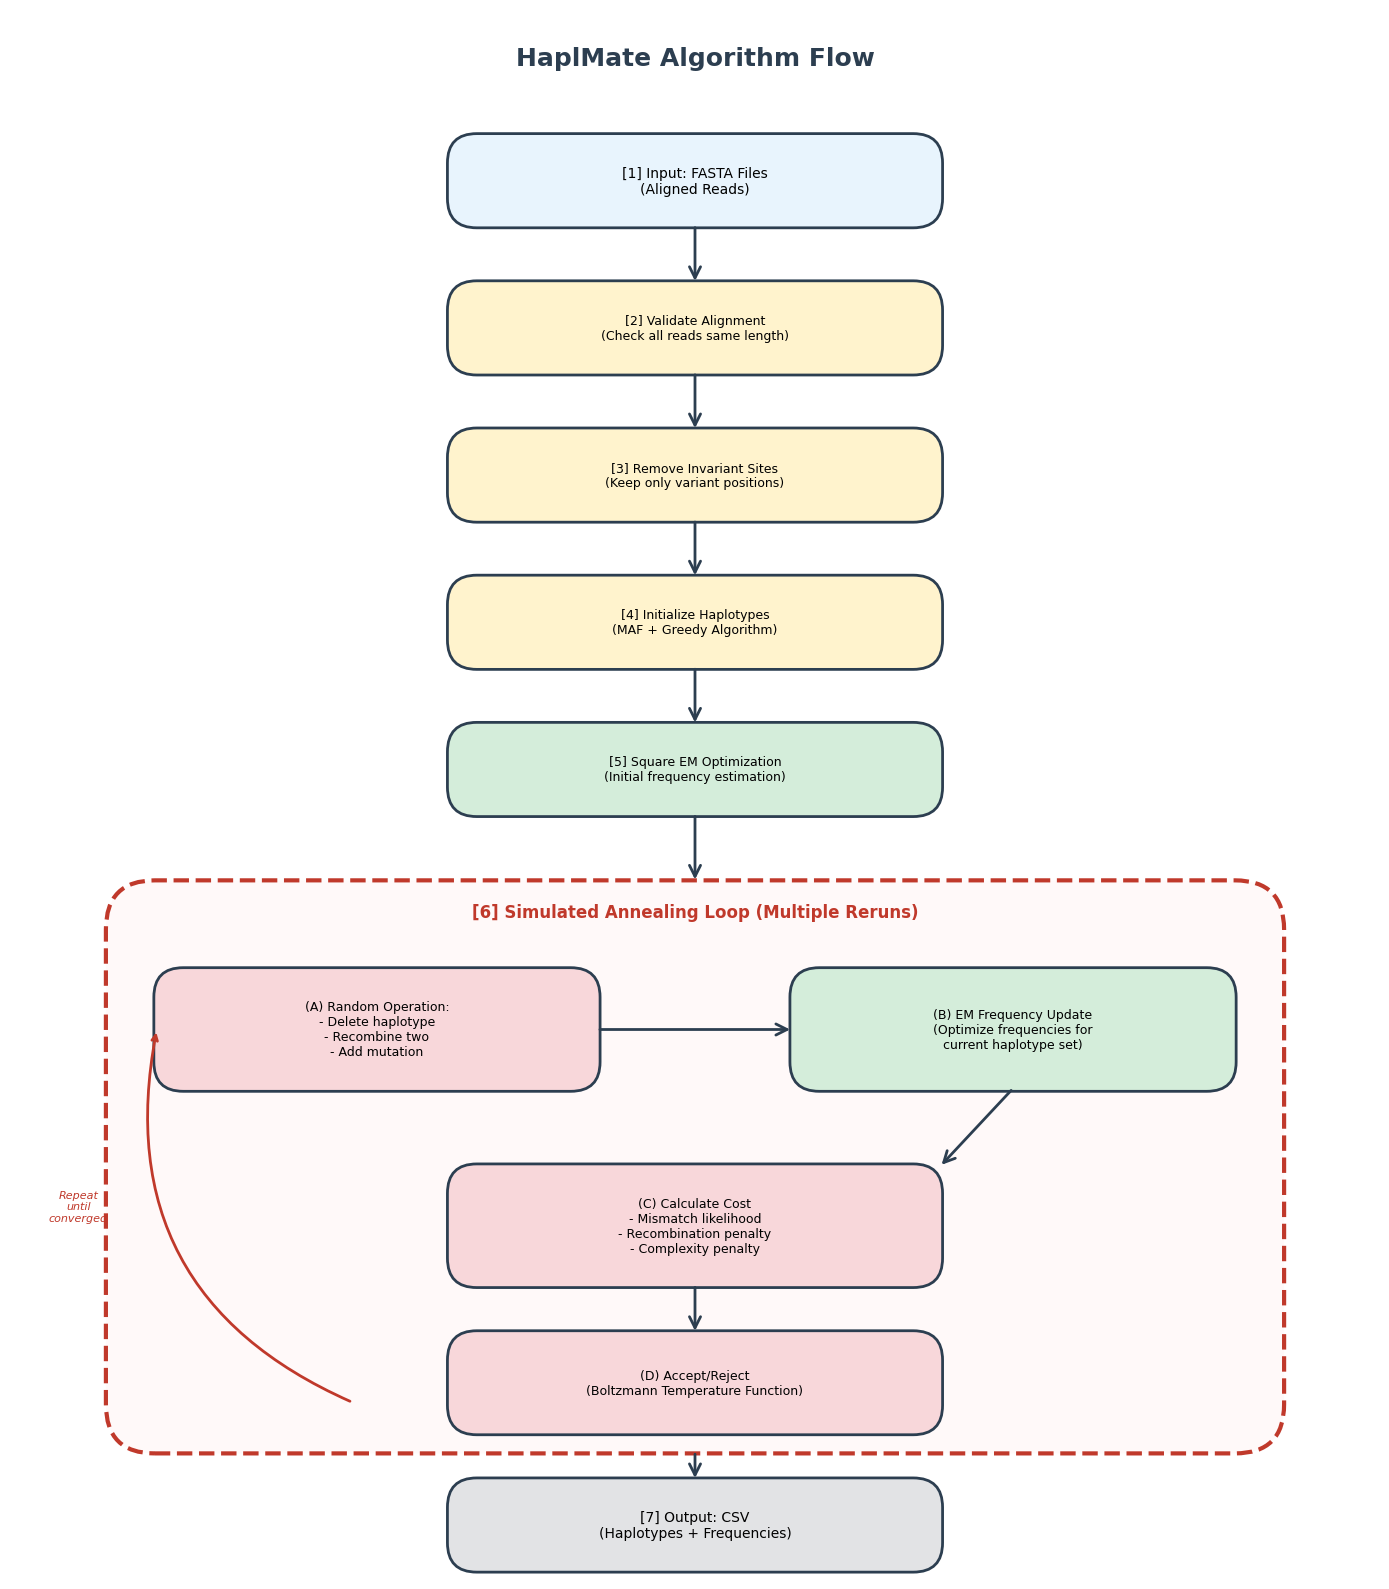

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

def create_algorithm_flowchart():
    """Create a visual flowchart of the HaplMate algorithm."""
    fig, ax = plt.subplots(1, 1, figsize=(14, 16))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 16)
    ax.axis('off')
    
    # Color scheme
    colors = {
        'input': '#E8F4FD',      # Light blue
        'init': '#FFF3CD',       # Light yellow
        'em': '#D4EDDA',         # Light green
        'sa': '#F8D7DA',         # Light pink/red
        'output': '#E2E3E5',     # Light gray
        'border': '#2C3E50',     # Dark blue-gray
    }
    
    def draw_box(x, y, w, h, text, color, fontsize=11, bold=False):
        """Draw a rounded box with text."""
        box = FancyBboxPatch((x, y), w, h, 
                             boxstyle="round,pad=0.03,rounding_size=0.3",
                             facecolor=color, edgecolor=colors['border'], linewidth=2)
        ax.add_patch(box)
        weight = 'bold' if bold else 'normal'
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', 
                fontsize=fontsize, weight=weight, wrap=True)
    
    def draw_arrow(x1, y1, x2, y2, curved=False):
        """Draw an arrow between two points."""
        if curved:
            style = "arc3,rad=0.3"
        else:
            style = "arc3,rad=0"
        arrow = FancyArrowPatch((x1, y1), (x2, y2),
                                arrowstyle='->', mutation_scale=20,
                                color=colors['border'], linewidth=2,
                                connectionstyle=style)
        ax.add_patch(arrow)
    
    # Title
    ax.text(7, 15.5, "HaplMate Algorithm Flow", ha='center', va='center', 
            fontsize=18, weight='bold', color=colors['border'])
    
    # ==========  INPUT STAGE ==========
    draw_box(4.5, 13.8, 5, 0.9, "[1] Input: FASTA Files\n(Aligned Reads)", colors['input'], fontsize=10)
    
    # ==========  PREPROCESSING ==========
    draw_box(4.5, 12.3, 5, 0.9, "[2] Validate Alignment\n(Check all reads same length)", colors['init'], fontsize=9)
    draw_arrow(7, 13.8, 7, 13.2)
    
    draw_box(4.5, 10.8, 5, 0.9, "[3] Remove Invariant Sites\n(Keep only variant positions)", colors['init'], fontsize=9)
    draw_arrow(7, 12.3, 7, 11.7)
    
    # ==========  INITIALIZATION ==========
    draw_box(4.5, 9.3, 5, 0.9, "[4] Initialize Haplotypes\n(MAF + Greedy Algorithm)", colors['init'], fontsize=9)
    draw_arrow(7, 10.8, 7, 10.2)
    
    # ==========  INITIAL EM ==========
    draw_box(4.5, 7.8, 5, 0.9, "[5] Square EM Optimization\n(Initial frequency estimation)", colors['em'], fontsize=9)
    draw_arrow(7, 9.3, 7, 8.7)
    
    # ==========  SA LOOP ==========
    # SA outer box
    sa_box = FancyBboxPatch((1, 1.3), 12, 5.8, 
                            boxstyle="round,pad=0.02,rounding_size=0.5",
                            facecolor='#FFF9F9', edgecolor='#C0392B', 
                            linewidth=3, linestyle='--')
    ax.add_patch(sa_box)
    ax.text(7, 6.8, "[6] Simulated Annealing Loop (Multiple Reruns)", 
            ha='center', va='center', fontsize=12, weight='bold', color='#C0392B')
    
    draw_arrow(7, 7.8, 7, 7.1)
    
    # Inside SA loop
    draw_box(1.5, 5.0, 4.5, 1.2, "(A) Random Operation:\n- Delete haplotype\n- Recombine two\n- Add mutation", 
             colors['sa'], fontsize=9)
    
    draw_box(8, 5.0, 4.5, 1.2, "(B) EM Frequency Update\n(Optimize frequencies for\ncurrent haplotype set)", 
             colors['em'], fontsize=9)
    
    draw_box(4.5, 3.0, 5, 1.2, "(C) Calculate Cost\n- Mismatch likelihood\n- Recombination penalty\n- Complexity penalty", 
             colors['sa'], fontsize=9)
    
    draw_box(4.5, 1.5, 5, 1.0, "(D) Accept/Reject\n(Boltzmann Temperature Function)", colors['sa'], fontsize=9)
    
    # Arrows inside SA
    draw_arrow(6, 5.6, 8, 5.6)  # Operation -> EM
    draw_arrow(10.25, 5.0, 9.5, 4.2)  # EM -> Cost
    draw_arrow(7, 3.0, 7, 2.5)  # Cost -> Accept
    
    # Loop back arrow
    ax.annotate('', xy=(1.5, 5.6), xytext=(3.5, 1.8),
                arrowprops=dict(arrowstyle='->', color='#C0392B', lw=2,
                               connectionstyle='arc3,rad=-0.4'))
    ax.text(0.7, 3.8, "Repeat\nuntil\nconverged", ha='center', va='center', 
            fontsize=8, color='#C0392B', style='italic')
    
    # ==========  OUTPUT ==========
    draw_box(4.5, 0.1, 5, 0.9, "[7] Output: CSV\n(Haplotypes + Frequencies)", colors['output'], fontsize=10)
    draw_arrow(7, 1.3, 7, 1.0)
    
    plt.tight_layout()
    return fig

fig = create_algorithm_flowchart()
plt.show()


---

### 4️⃣ Simulated Annealing (SA) - The Outer Loop

While EM only optimizes **frequencies**, SA explores the **structure** of the haplotype set (which haplotypes exist).

#### The Three Operations (Randomly Chosen Each Step)


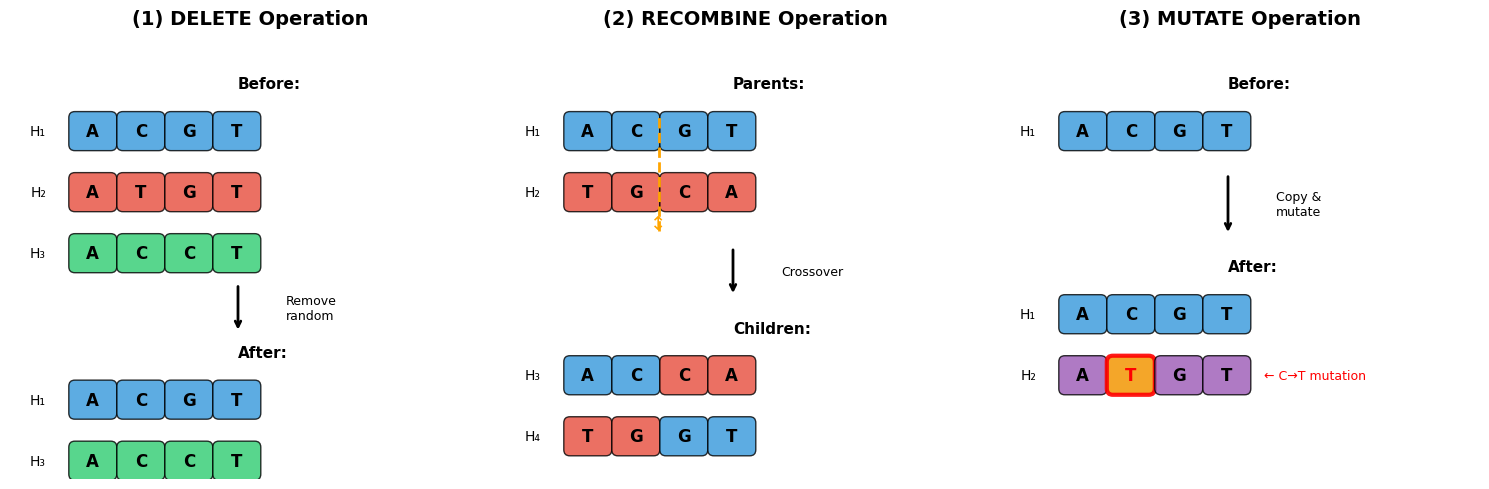

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch
import numpy as np

def draw_sa_operations():
    """Visualize the three SA operations."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    colors = {
        'hap1': '#3498DB',  # Blue
        'hap2': '#E74C3C',  # Red  
        'hap3': '#2ECC71',  # Green
        'new': '#9B59B6',   # Purple
        'bg': '#F8F9FA',
    }
    
    def draw_haplotype(ax, x, y, seq, color, label=''):
        """Draw a haplotype as a sequence of colored boxes."""
        box_w, box_h = 0.4, 0.3
        for i, nuc in enumerate(seq):
            rect = FancyBboxPatch((x + i * box_w, y), box_w - 0.02, box_h,
                                  boxstyle="round,pad=0.01,rounding_size=0.05",
                                  facecolor=color, edgecolor='black', linewidth=1, alpha=0.8)
            ax.add_patch(rect)
            ax.text(x + i * box_w + box_w/2 - 0.01, y + box_h/2, nuc, 
                    ha='center', va='center', fontsize=12, fontweight='bold')
        if label:
            ax.text(x - 0.2, y + box_h/2, label, ha='right', va='center', fontsize=10)
    
    # ============ OPERATION 1: DELETE ============
    ax = axes[0]
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.5, 3)
    ax.axis('off')
    ax.set_title("(1) DELETE Operation", fontsize=14, fontweight='bold', pad=20)
    
    # Before
    ax.text(1.4, 2.7, "Before:", fontsize=11, fontweight='bold')
    draw_haplotype(ax, 0, 2.2, "ACGT", colors['hap1'], "H₁")
    draw_haplotype(ax, 0, 1.7, "ATGT", colors['hap2'], "H₂")
    draw_haplotype(ax, 0, 1.2, "ACCT", colors['hap3'], "H₃")
    
    # Arrow
    ax.annotate('', xy=(1.4, 0.7), xytext=(1.4, 1.1),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(1.8, 0.9, "Remove\nrandom", fontsize=9, va='center')
    
    # After
    ax.text(1.4, 0.5, "After:", fontsize=11, fontweight='bold')
    draw_haplotype(ax, 0, 0.0, "ACGT", colors['hap1'], "H₁")
    draw_haplotype(ax, 0, -0.5, "ACCT", colors['hap3'], "H₃")
    
    # ============ OPERATION 2: RECOMBINE ============
    ax = axes[1]
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.5, 3)
    ax.axis('off')
    ax.set_title("(2) RECOMBINE Operation", fontsize=14, fontweight='bold', pad=20)
    
    # Before - parents
    ax.text(1.4, 2.7, "Parents:", fontsize=11, fontweight='bold')
    draw_haplotype(ax, 0, 2.2, "ACGT", colors['hap1'], "H₁")
    draw_haplotype(ax, 0, 1.7, "TGCA", colors['hap2'], "H₂")
    
    # Crossover point marker
    ax.axvline(x=0.78, ymin=0.58, ymax=0.85, color='orange', linestyle='--', linewidth=2)
    ax.text(0.78, 1.55, "↕", fontsize=14, ha='center', color='orange')
    
    # Arrow
    ax.annotate('', xy=(1.4, 1.0), xytext=(1.4, 1.4),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(1.8, 1.2, "Crossover", fontsize=9, va='center')
    
    # After - children
    ax.text(1.4, 0.7, "Children:", fontsize=11, fontweight='bold')
    # Child 1: AC from H1 + CA from H2
    for i, (nuc, col) in enumerate([('A', colors['hap1']), ('C', colors['hap1']), 
                                      ('C', colors['hap2']), ('A', colors['hap2'])]):
        box_w, box_h = 0.4, 0.3
        rect = FancyBboxPatch((0 + i * box_w, 0.2), box_w - 0.02, box_h,
                              boxstyle="round,pad=0.01,rounding_size=0.05",
                              facecolor=col, edgecolor='black', linewidth=1, alpha=0.8)
        ax.add_patch(rect)
        ax.text(0 + i * box_w + box_w/2 - 0.01, 0.2 + box_h/2, nuc, 
                ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(-0.2, 0.35, "H₃", ha='right', va='center', fontsize=10)
    
    # Child 2: TG from H2 + GT from H1
    for i, (nuc, col) in enumerate([('T', colors['hap2']), ('G', colors['hap2']), 
                                      ('G', colors['hap1']), ('T', colors['hap1'])]):
        box_w, box_h = 0.4, 0.3
        rect = FancyBboxPatch((0 + i * box_w, -0.3), box_w - 0.02, box_h,
                              boxstyle="round,pad=0.01,rounding_size=0.05",
                              facecolor=col, edgecolor='black', linewidth=1, alpha=0.8)
        ax.add_patch(rect)
        ax.text(0 + i * box_w + box_w/2 - 0.01, -0.3 + box_h/2, nuc, 
                ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(-0.2, -0.15, "H₄", ha='right', va='center', fontsize=10)
    
    # ============ OPERATION 3: MUTATE ============
    ax = axes[2]
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.5, 3)
    ax.axis('off')
    ax.set_title("(3) MUTATE Operation", fontsize=14, fontweight='bold', pad=20)
    
    # Before
    ax.text(1.4, 2.7, "Before:", fontsize=11, fontweight='bold')
    draw_haplotype(ax, 0, 2.2, "ACGT", colors['hap1'], "H₁")
    
    # Arrow
    ax.annotate('', xy=(1.4, 1.5), xytext=(1.4, 2.0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(1.8, 1.75, "Copy &\nmutate", fontsize=9, va='center')
    
    # After
    ax.text(1.4, 1.2, "After:", fontsize=11, fontweight='bold')
    draw_haplotype(ax, 0, 0.7, "ACGT", colors['hap1'], "H₁")
    
    # Mutated copy with highlight on mutation
    for i, (nuc, col) in enumerate([('A', colors['new']), ('C', colors['new']), 
                                      ('G', colors['new']), ('T', colors['new'])]):
        box_w, box_h = 0.4, 0.3
        # Highlight the mutated position
        if i == 1:  # Position being mutated
            rect = FancyBboxPatch((0 + i * box_w, 0.2), box_w - 0.02, box_h,
                                  boxstyle="round,pad=0.01,rounding_size=0.05",
                                  facecolor='#F39C12', edgecolor='red', linewidth=3, alpha=0.9)
            ax.add_patch(rect)
            ax.text(0 + i * box_w + box_w/2 - 0.01, 0.2 + box_h/2, 'T', 
                    ha='center', va='center', fontsize=12, fontweight='bold', color='red')
        else:
            rect = FancyBboxPatch((0 + i * box_w, 0.2), box_w - 0.02, box_h,
                                  boxstyle="round,pad=0.01,rounding_size=0.05",
                                  facecolor=col, edgecolor='black', linewidth=1, alpha=0.8)
            ax.add_patch(rect)
            ax.text(0 + i * box_w + box_w/2 - 0.01, 0.2 + box_h/2, nuc, 
                    ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(-0.2, 0.35, "H₂", ha='right', va='center', fontsize=10)
    ax.text(1.7, 0.35, "← C→T mutation", fontsize=9, va='center', color='red')
    
    plt.tight_layout()
    return fig

fig = draw_sa_operations()
plt.show()


---

# Analysis Section

The cells below contain the actual post-analysis of haplotype estimation results.


In [14]:
# Parameters
true_haplotypes = "5000reads_true_haplotypes.csv"
estimation_count = 6

In [10]:
import re
import plotly.graph_objects as go
import numpy as np
from pathlib import Path
from typing import Optional, Tuple


def parse_hm_log(log_path: str) -> Tuple[list[float], list[Tuple[int, int]]]:
    """
    Parse a haplmate log file to extract total costs and SA start positions.
    
    Args:
        log_path: Path to the log file
        
    Returns:
        Tuple of (costs, sa_starts) where:
        - costs: List of total cost values in order
        - sa_starts: List of (iteration_index, n_haplotypes) tuples marking SA starts
    """
    # Regex to strip ANSI escape codes
    ansi_escape = re.compile(r'\x1b\[[0-9;]*m')
    
    # Patterns to match
    sa_start_pattern = re.compile(r'Running SA with (\d+) haplotypes, iteration (\d+)')
    total_cost_pattern = re.compile(r'Total cost: ([\d.]+)')
    
    costs = []
    sa_starts = []  # (iteration_index, n_haplotypes)
    
    with open(log_path, 'r') as f:
        for line in f:
            # Strip ANSI codes
            clean_line = ansi_escape.sub('', line)
            
            # Check for SA start
            sa_match = sa_start_pattern.search(clean_line)
            if sa_match:
                n_haplotypes = int(sa_match.group(1))
                # The SA start occurs at the current cost count (before adding new costs)
                sa_starts.append((len(costs), n_haplotypes))
                continue
            
            # Check for total cost
            cost_match = total_cost_pattern.search(clean_line)
            if cost_match:
                costs.append(float(cost_match.group(1)))
    
    return costs, sa_starts


def minmax_downsample(x: np.ndarray, y: np.ndarray, max_points: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Downsample data using min-max method to preserve visual shape.
    
    For each bucket, keeps the min and max values to preserve peaks and valleys.
    This gives 2 points per bucket, maintaining the visual appearance of the data.
    """
    n = len(x)
    if n <= max_points:
        return x, y
    
    # Number of buckets (each bucket produces 2 points: min and max)
    n_buckets = max_points // 2
    bucket_size = n / n_buckets
    
    x_downsampled = []
    y_downsampled = []
    
    for i in range(n_buckets):
        start_idx = int(i * bucket_size)
        end_idx = int((i + 1) * bucket_size)
        
        if start_idx >= n:
            break
            
        end_idx = min(end_idx, n)
        bucket_y = y[start_idx:end_idx]
        bucket_x = x[start_idx:end_idx]
        
        if len(bucket_y) == 0:
            continue
        
        # Find min and max indices within this bucket
        min_idx = np.argmin(bucket_y)
        max_idx = np.argmax(bucket_y)
        
        # Add in order of x value to maintain line continuity
        if min_idx <= max_idx:
            x_downsampled.extend([bucket_x[min_idx], bucket_x[max_idx]])
            y_downsampled.extend([bucket_y[min_idx], bucket_y[max_idx]])
        else:
            x_downsampled.extend([bucket_x[max_idx], bucket_x[min_idx]])
            y_downsampled.extend([bucket_y[max_idx], bucket_y[min_idx]])
    
    return np.array(x_downsampled), np.array(y_downsampled)


def plot_optimization_progress(
    hm_log: str,
    title: Optional[str] = None,
    height: int = 600,
    width: int = 1200,
    max_points: int = 5000,
) -> go.Figure:
    """
    Plot the optimization progress from a haplmate log file (interactive).
    
    Args:
        hm_log: Path to the log file
        title: Optional title for the plot. Defaults to the log filename.
        height: Figure height in pixels
        width: Figure width in pixels
        max_points: Maximum number of points to display (downsamples if exceeded).
                   Uses min-max downsampling to preserve visual shape.
                   Set to None to disable downsampling.
        
    Returns:
        Plotly Figure object (interactive - use mouse to zoom, pan, hover)
    """
    log_path = Path(hm_log)
    costs, sa_starts = parse_hm_log(hm_log)
    
    if not costs:
        print("No cost data found in log file!")
        return None
    
    iterations = np.arange(len(costs))
    costs_arr = np.array(costs)
    
    # Downsample if needed
    if max_points is not None and len(costs) > max_points:
        print(f"Downsampling {len(costs):,} points to ~{max_points:,} for performance...")
        x_plot, y_plot = minmax_downsample(iterations, costs_arr, max_points)
    else:
        x_plot, y_plot = iterations, costs_arr
    
    # Create figure
    fig = go.Figure()
    
    # Add total cost trace
    fig.add_trace(go.Scattergl(
        x=x_plot,
        y=y_plot,
        mode='lines',
        name='Total cost',
        line=dict(color='#1f77b4', width=1),
        hovertemplate='Iteration: %{x:,.0f}<br>Cost: %{y:,.2f}<extra></extra>'
    ))
    
    # Add vertical lines for SA starts with different colors
    y_min = float(costs_arr.min())
    y_max = float(costs_arr.max())
    
    # Color palette for SA iterations (colorblind-friendly)
    sa_colors = [
        '#e41a1c',  # Red
        '#377eb8',  # Blue
        '#4daf4a',  # Green
        '#984ea3',  # Purple
        '#ff7f00',  # Orange
        '#a65628',  # Brown
        '#f781bf',  # Pink
        '#999999',  # Gray
        '#66c2a5',  # Teal
        '#fc8d62',  # Coral
    ]
    
    for i, (sa_iter, n_haplotypes) in enumerate(sa_starts):
        color = sa_colors[i % len(sa_colors)]
        label = f'SA iter {i+1} (n={n_haplotypes})'
        fig.add_trace(go.Scatter(
            x=[sa_iter, sa_iter],
            y=[y_min, y_max],
            mode='lines',
            name=label,
            line=dict(color=color, width=2, dash='dash'),
            hovertemplate=f'{label}<br>Start at iteration: {sa_iter:,}<extra></extra>'
        ))
    
    # Update layout
    fig.update_layout(
        title=title or log_path.name,
        xaxis_title='Iteration',
        yaxis_title='Total cost',
        height=height,
        width=width,
        hovermode='closest',
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="right",
            x=0.99
        ),
        # Enable range slider for easy navigation
        xaxis=dict(
            rangeslider=dict(visible=True),
            type='linear'
        )
    )
    
    # Configure zoom/pan behavior
    fig.update_xaxes(fixedrange=False)
    fig.update_yaxes(fixedrange=False)
    
    return fig


Downsampling 312,669 points to ~10,000 for performance...


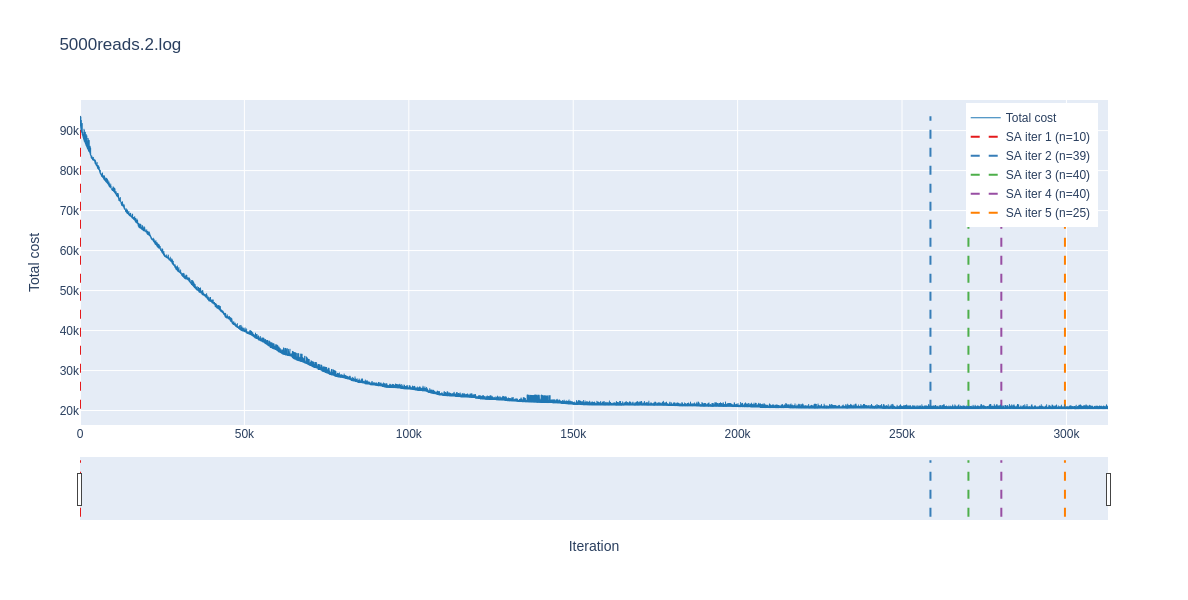

In [12]:
# Example usage:
# Returns an interactive Plotly figure - use mouse to:
#   - Zoom: Click and drag to select a region, or use scroll wheel
#   - Pan: Hold shift + drag, or use the pan tool in the toolbar
#   - Reset: Double-click to reset view
#   - Range slider: Use the slider at the bottom for quick navigation

# Default: downsamples to 5000 points for smooth interaction
# fig = plot_optimization_progress("5000reads.2.log")
# fig.show()

# For more detail (but may be slower): increase max_points
fig = plot_optimization_progress("5000reads.2.log", max_points=10000)
fig.show()

# To show all points (may crash on large files):
# fig = plot_optimization_progress("5000reads.2.log", max_points=None)


In [ ]:
import pandas as pd
from pathlib import Path
from typing import Optional


def compare_haplotypes(
    true_csv: str,
    estimated_csv: str,
    seq_column: int = 0,
) -> dict:
    """
    Compare estimated haplotypes against true haplotypes.
    
    Args:
        true_csv: Path to the CSV containing true haplotypes
        estimated_csv: Path to the CSV containing estimated haplotypes
        seq_column: Column index containing the sequence (default: 0, first column)
    
    Returns:
        Dictionary containing comparison results
    """
    # Read CSVs - use first column as sequence
    true_df = pd.read_csv(true_csv)
    est_df = pd.read_csv(estimated_csv)
    
    # Get sequences from first column
    true_seqs = set(true_df.iloc[:, seq_column].astype(str))
    est_seqs = set(est_df.iloc[:, seq_column].astype(str))
    
    # Calculate set comparisons
    correct = true_seqs & est_seqs  # Intersection: correctly estimated
    missed = true_seqs - est_seqs   # In true but not estimated
    spurious = est_seqs - true_seqs # Estimated but not in true
    
    return {
        'true_count': len(true_seqs),
        'estimated_count': len(est_seqs),
        'correct': correct,
        'correct_count': len(correct),
        'missed': missed,
        'missed_count': len(missed),
        'spurious': spurious,
        'spurious_count': len(spurious),
        'recall': len(correct) / len(true_seqs) if true_seqs else 0.0,
        'precision': len(correct) / len(est_seqs) if est_seqs else 0.0,
    }


def check_haplotype_estimation(
    true_csv: str,
    estimated_csvs: list[str],
    seq_column: int = 0,
    show_sequences: bool = False,
) -> pd.DataFrame:
    """
    Check multiple haplotype estimations against the true haplotypes.
    
    Args:
        true_csv: Path to the CSV containing true haplotypes
        estimated_csvs: List of paths to estimated haplotype CSVs
        seq_column: Column index containing the sequence (default: 0)
        show_sequences: If True, print the actual sequences that were missed/spurious
    
    Returns:
        DataFrame summarizing the comparison results
    """
    results = []
    
    for est_csv in estimated_csvs:
        est_path = Path(est_csv)
        comparison = compare_haplotypes(true_csv, est_csv, seq_column)
        
        results.append({
            'Estimation': e;st_path.name,
            'True': comparison['true_count'],
            'Estimated': comparison['estimated_count'],
            'Correct': comparison['correct_count'],
            'Missed': comparison['missed_count'],
            'Spurious': comparison['spurious_count'],
            'Recall': f"{comparison['recall']:.2%}",
            'Precision': f"{comparison['precision']:.2%}",
        })
        
        if show_sequences:
            print(f"\n{'='*60}")
            print(f"📁 {est_path.name}")
            print(f"{'='*60}")
            
            if comparison['correct']:
                print(f"\n✅ Correctly estimated ({comparison['correct_count']}):")
                for seq in sorted(comparison['correct']):
                    print(f"   {seq[:60]}{'...' if len(seq) > 60 else ''}")
            
            if comparison['missed']:
                print(f"\n❌ Missed (in true, not estimated) ({comparison['missed_count']}):")
                for seq in sorted(comparison['missed']):
                    print(f"   {seq[:60]}{'...' if len(seq) > 60 else ''}")
            
            if comparison['spurious']:
                print(f"\n⚠️  Spurious (estimated, not in true) ({comparison['spurious_count']}):")
                for seq in sorted(comparison['spurious']):
                    print(f"   {seq[:60]}{'...' if len(seq) > 60 else ''}")
    
    return pd.DataFrame(results)


In [16]:
# Check if estimated haplotypes match the true haplotypes
# Uses the parameters defined above: true_haplotypes and estimation_count

# Build list of estimated haplotype CSV paths
# Adjust the naming pattern to match your output files
# estimated_csvs = [f"estimated_haplotypes_{i}.csv" for i in range(1, estimation_count + 1)]
estimated_csvs = ["5000reads.3.csv"]

# Run the comparison
# Set show_sequences=True to see the actual sequences that were correct/missed/spurious
results_df = check_haplotype_estimation(
    true_csv=true_haplotypes,
    estimated_csvs=estimated_csvs,
    seq_column=0,  # Sequence is in first column
    show_sequences=True,
)

# Display summary table
print("\n" + "="*80)
print("📊 SUMMARY")
print("="*80)
display(results_df)



📁 5000reads.3.csv

❌ Missed (in true, not estimated) (5):
   GTTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTGTATCC...
   GTTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTGTATCC...
   GTTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTTTATCC...
   GTTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTTTATCC...
   GTTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTTTATCC...

⚠️  Spurious (estimated, not in true) (46):
   -TTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTGTATCC...
   -TTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTGTATCC...
   -TTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTTTATCC...
   -TTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTTTATCC...
   -TTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTTTATCC...
   -TTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTTTATCC...
   -TTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTTTATCC...
   -TTAATGTAGCTTAATAACAAAGCAAAGCACTGAAAATGCTTAGATGGATAATTTTATCC...
   -TTAATGTAGCTTAATAACAAA

,Estimation,True,Estimated,Correct,Missed,Spurious,Recall,Precision
0,5000reads.3.csv,5,46,0,5,46,0.00%,0.00%


---

# Haplotype Network Visualization with R (pegas)

This section creates **three haplotype network visualizations** using the R `pegas` library via the `haplotype_network.R` script.

## Output Images
1. **MST Only** - Clean minimum spanning tree showing the simplest connected structure
2. **Filtered Alternatives** - MST + top N alternative edges (configurable, sorted by lowest mutation count)
3. **All Edges** - MST + all possible alternative connections

## Legend
- **Dark blue circles**: Estimated True Haplotypes (correctly identified)
- **Light blue circles**: Not Estimated True Haplotypes (missed - in true but not estimated)
- **Yellow circles**: Estimated Not True Haplotypes (spurious - estimated but not in true)
- **Thick solid edges**: Minimum Spanning Tree (MST) connections
- **Thin dotted edges**: Alternative connections (non-MST)
- **Numbers on edges**: Mutation count between connected haplotypes
- **Circle size**: Proportional to haplotype frequency

## Usage
The R script `haplotype_network.R` takes 3-4 arguments:
```
Rscript haplotype_network.R <true_haplotypes.csv> <estimated_haplotypes.csv> <output_prefix> [num_alt_edges]
```
- `num_alt_edges`: Optional. Number of alternative edges to show in filtered view (default: 50). Edges are selected by lowest mutation count.

This generates: `<output_prefix>_mst_only.png`, `<output_prefix>_filtered.png`, `<output_prefix>_all.png`


In [17]:
# Generate Haplotype Network using R's pegas library
# This cell runs the haplotype_network.R script to create THREE visualizations:
# 1. MST only (clean tree)
# 2. Filtered alternatives (MST + top N alternative edges)
# 3. All edges (MST + all alternatives)

import subprocess
import os
from pathlib import Path
from IPython.display import Image, display, HTML

# ============================================
# CONFIGURATION - Adjust these parameters
# ============================================
true_haplotypes_file = "5000reads_true_haplotypes.csv"
estimated_haplotypes_file = "5000reads.3.csv"  
output_prefix = "haplotype_network"

# Number of alternative edges to show in the filtered view
# These are selected by lowest mutation count first
num_alt_edges = 50  # Change this to show more/fewer alternative edges

# R script path (in the same directory as this notebook)
r_script = "haplotype_network.R"
# ============================================

print(f"True haplotypes: {true_haplotypes_file}")
print(f"Estimated haplotypes: {estimated_haplotypes_file}")
print(f"Output prefix: {output_prefix}")
print(f"Alternative edges to show: {num_alt_edges}")
print("\n" + "="*60)

# Run the R script (now generates 3 images)
cmd = ["Rscript", r_script, true_haplotypes_file, estimated_haplotypes_file, output_prefix, str(num_alt_edges)]
print(f"Running: {' '.join(cmd)}\n")

result = subprocess.run(cmd, capture_output=True, text=True)

# Print output
if result.stdout:
    print(result.stdout)
if result.stderr:
    print("Warnings/Errors:", result.stderr)

if result.returncode != 0:
    print(f"\n❌ Error: R script failed with return code {result.returncode}")
else:
    print(f"\n✅ Success!")


True haplotypes: 5000reads_true_haplotypes.csv
Estimated haplotypes: 5000reads.3.csv
Output prefix: haplotype_network
Alternative edges to show: 50

Running: Rscript haplotype_network.R 5000reads_true_haplotypes.csv 5000reads.3.csv haplotype_network 50

Settings:
  Alternative edges to show: 50 
Reading haplotype files...

Haplotype categories:
  Estimated True (dark blue): 0 
  Not Estimated True (light blue): 5 
  Estimated Not True (yellow): 45 

Total unique haplotypes: 50 
Reading sequences and creating haplotype network...
Number of unique haplotypes: 50 

Edge summary:
  MST edges: 49 
  Non-MST edges: 1073 
  Filtered non-MST edges (top 50 by lowest mutations): 50 
  Max mutations in filtered set: 27 

Calculating network layout...
null device 
          1 

Generating three versions of the network

Generating: haplotype_network_mst_only.png 
null device 
          1 
Generating: haplotype_network_filtered.png 
null device 
          1 
Generating: haplotype_network_all.png 
nu

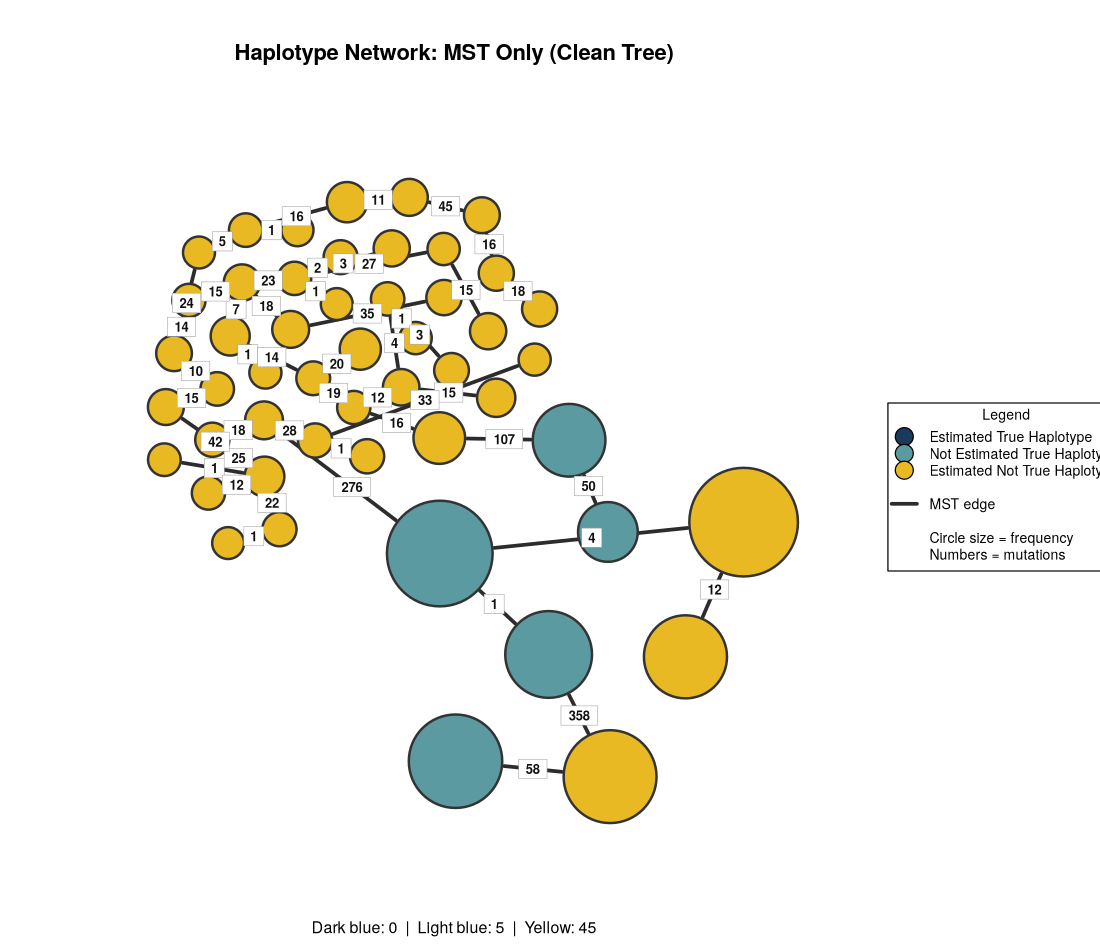

Saved to: /home/robin/Projects/haplmate/analysis/haplotype_network_mst_only.png

--------------------------------------------------------------------------------



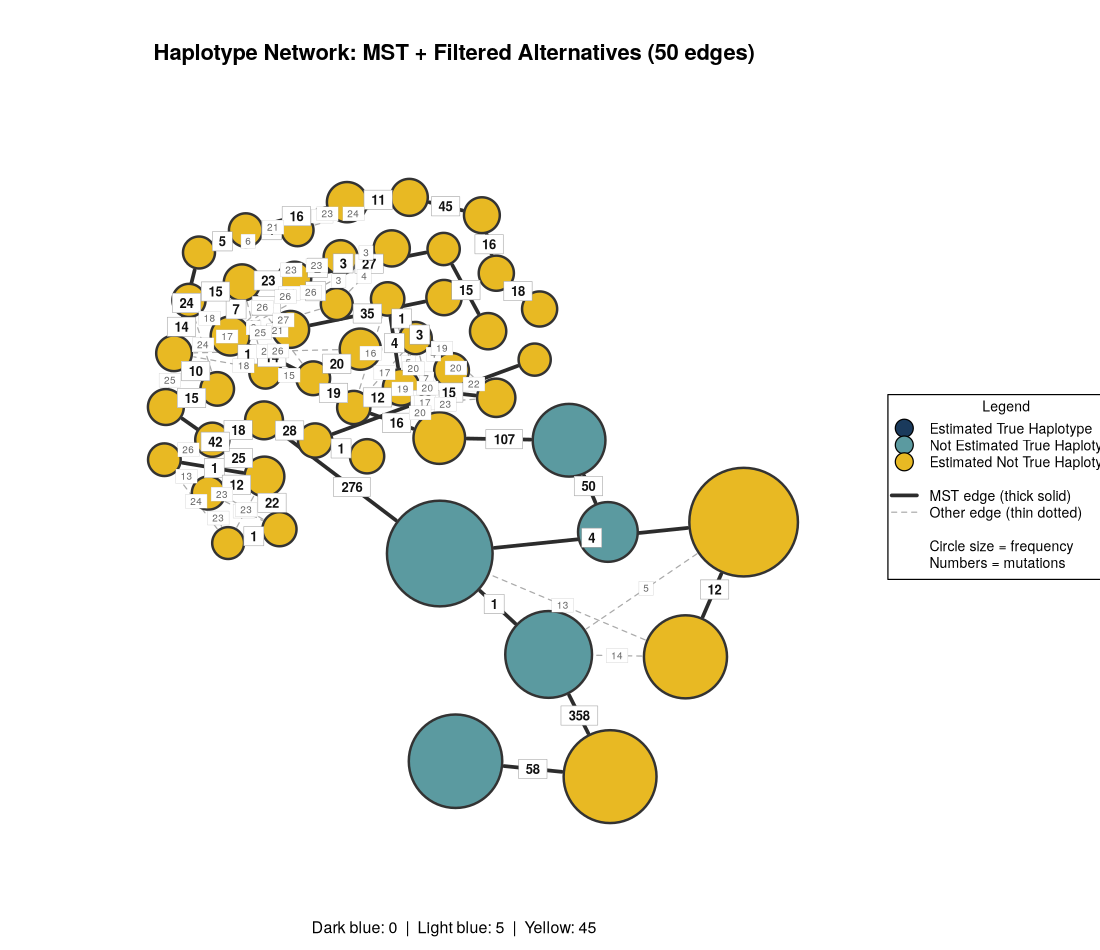

Saved to: /home/robin/Projects/haplmate/analysis/haplotype_network_filtered.png

--------------------------------------------------------------------------------



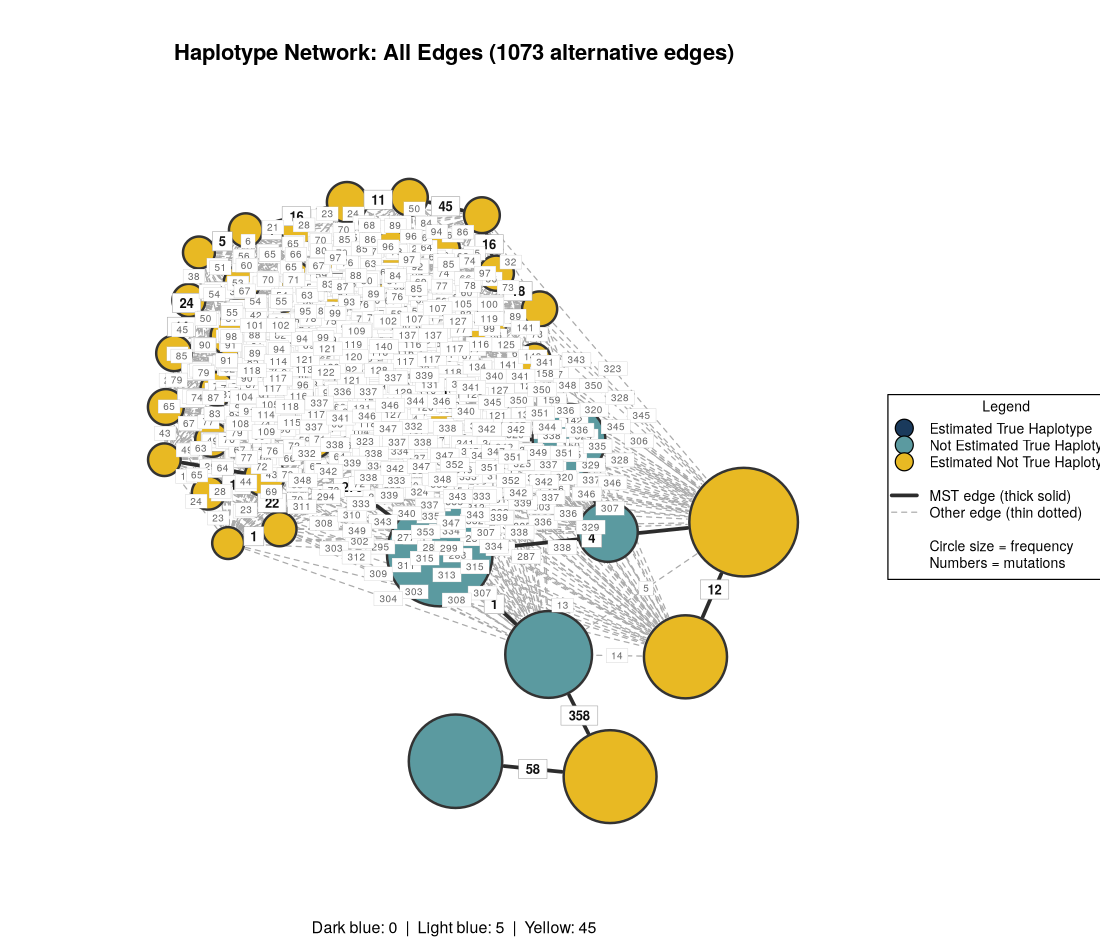

Saved to: /home/robin/Projects/haplmate/analysis/haplotype_network_all.png

--------------------------------------------------------------------------------


✅ All three network visualizations displayed above.


In [18]:
# Display all three haplotype network images
from IPython.display import Image, display, HTML
import os

output_prefix = "haplotype_network"
num_alt_edges = 50  # Should match the value from the previous cell

# Three output files
images = [
    (f"{output_prefix}_mst_only.png", "1. MST Only (Clean Tree)", 
     "Shows only the minimum spanning tree - the simplest connected structure"),
    (f"{output_prefix}_filtered.png", f"2. MST + Top {num_alt_edges} Alternative Edges", 
     f"MST (thick) + {num_alt_edges} alternative edges with lowest mutations (dotted)"),
    (f"{output_prefix}_all.png", "3. All Edges", 
     "MST (thick) + all alternative connections (dotted)"),
]

for img_path, title, description in images:
    if os.path.exists(img_path):
        display(HTML(f"<h2 style='color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 5px;'>{title}</h2>"))
        display(HTML(f"<p style='color: #666; font-style: italic;'>{description}</p>"))
        display(Image(filename=img_path))
        print(f"Saved to: {os.path.abspath(img_path)}\n")
        print("-" * 80 + "\n")
    else:
        print(f"❌ Error: Image not found at {img_path}")

print("\n✅ All three network visualizations displayed above.")
